ERROR: You must give at least one requirement to install (see "pip help install")
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 34.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!



Distribuição das classes no treino:
sentimento
positivo    627
negativo    546
neutro      527
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128079 (\N{CLAPPING HANDS SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127463 (\N{REGIONAL INDICATOR SYMBOL LETTER B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127479 (\N{REGIONAL INDICATOR SYMBOL LETTER R}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


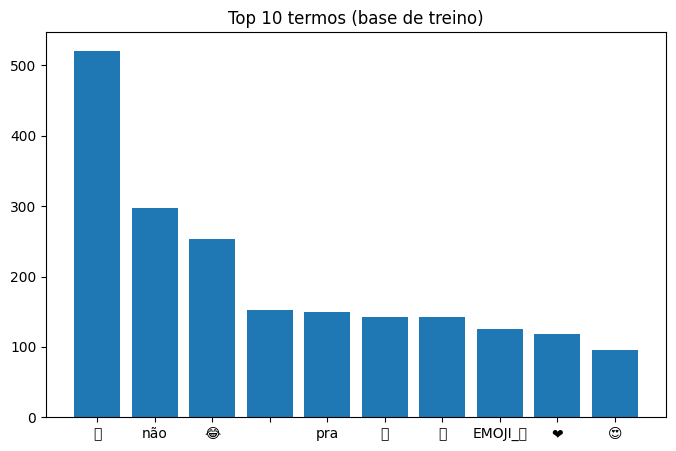

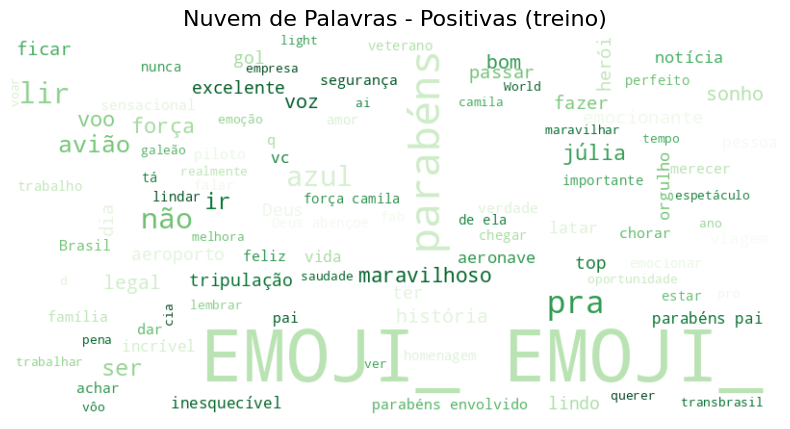

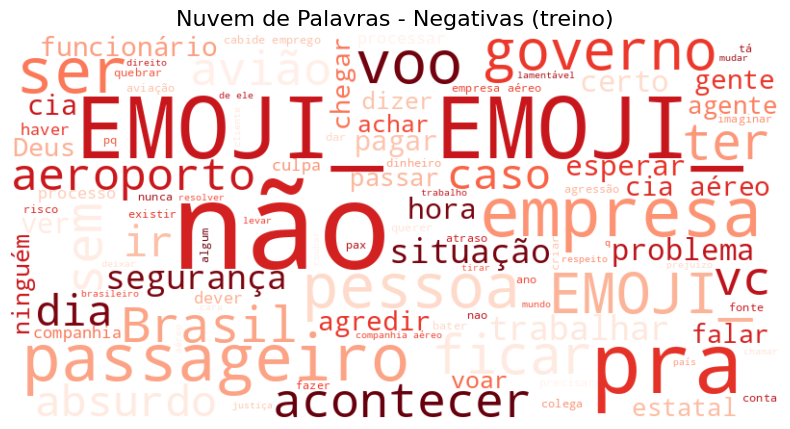


ACCURACY: 0.6215686274509804

RELATÓRIO COMPLETO:
               precision    recall  f1-score   support

    negativo       0.71      0.65      0.68       164
      neutro       0.60      0.33      0.42       158
    positivo       0.58      0.85      0.69       188

    accuracy                           0.62       510
   macro avg       0.63      0.61      0.60       510
weighted avg       0.63      0.62      0.60       510



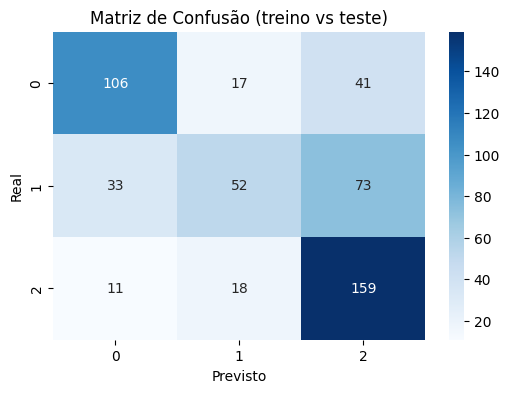


=== RESULTADOS DA CLASSIFICAÇÃO (comments_embarque.xlsx) ===
                     Quantidade  Percentual (%)
sentimento_previsto                            
positivo                   1124           87.54
negativo                     90            7.01
neutro                       70            5.45


/tmp/ipykernel_5833/2582330333.py:238: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=resultados.index, y=resultados["Percentual (%)"],


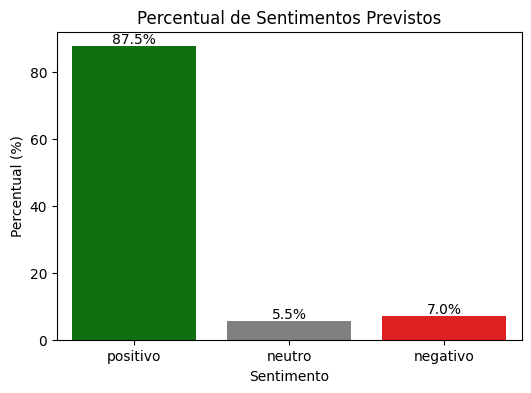

/tmp/ipykernel_5833/2582330333.py:252: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=novo_df, x="sentimento_previsto", order=["positivo", "neutro", "negativo"],


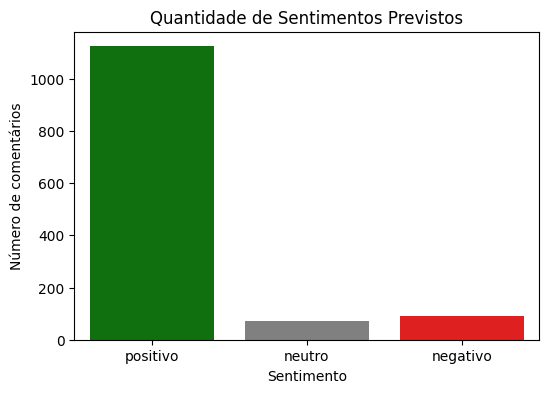

/tmp/ipykernel_5833/2582330333.py:279: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_emocoes, x="Emoção", y="Frequência", palette="viridis")



=== EMOÇÕES ENCONTRADAS NOS COMENTÁRIOS ===
Alegria: 38 ocorrências
Amor: 12 ocorrências
Raiva: 3 ocorrências
Tristeza: 3 ocorrências
Neutralidade: 2 ocorrências


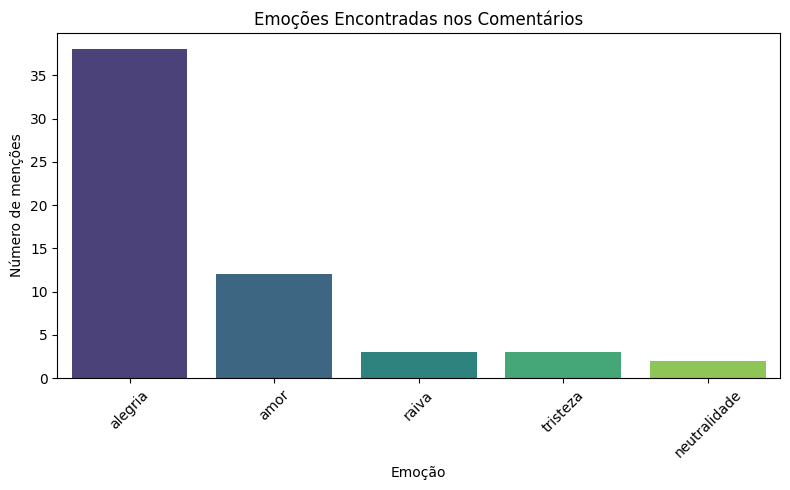

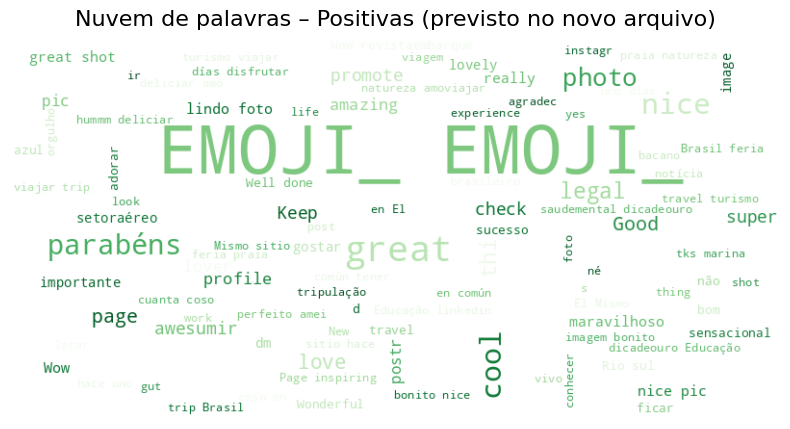

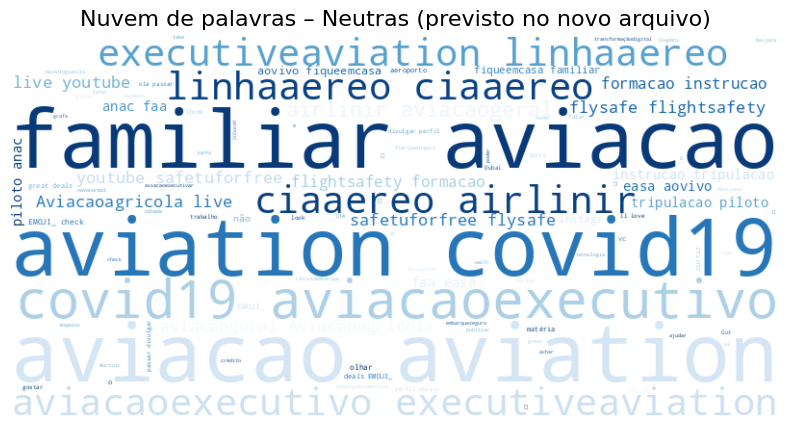

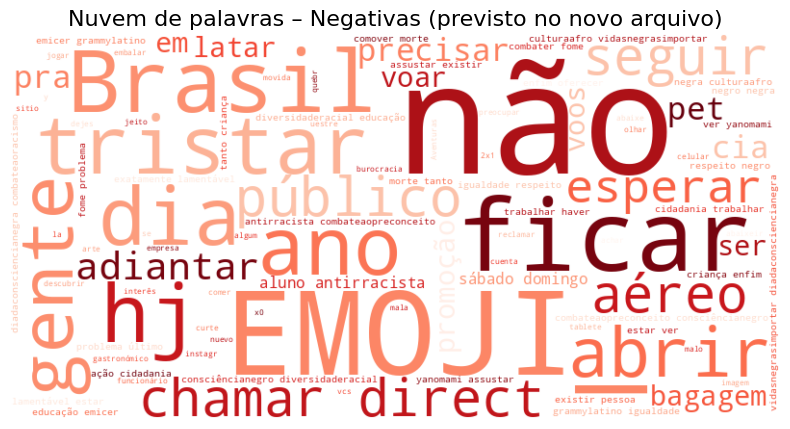


Arquivo com previsões e emoções salvo como 'comments_embarque_classificado.xlsx'


In [20]:
# CÓDIGO 01 - PARA A ANALISE DE SENTIMENTOS ESTE CÓDIGO DEVE SER EXECUTADO PRIMEIRO
# ########################################################################################################
# Este código tem como objetivo  a Análise de Sentimentos
# Importa as Módulos do Python para a Análise e estabelece regras lexicas, através de dicionários de emojis
# O Modelo gerado de comentarios inéditos
# Utiliza  técnicas de PLN  e Machine Learning
# Importação dos Módulos do Python
# #####################################################################################################


# instalação de pacotes
!pip install
!pip install nltk
!pip install emoji
!python -m spacy download pt_core_news_sm


import nltk
import spacy
nltk.download('stopwords')
nltk.download('punkt')
nlp = spacy.load("pt_core_news_sm")



import os
import re
import pandas as pd
import emoji
from collections import Counter
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
#from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# Esta linha foi incluída para ajustes caso a chamada os spacy
# não funcione corretamente

try:
    nlp = spacy.load("pt_core_news_sm")
except:
    os.system("python -m spacy download pt_core_news_sm")
    nlp = spacy.load("pt_core_news_sm")

# DADOS DE TREINO

negativos = pd.read_csv("500_negativos.csv")
neutros   = pd.read_csv("500_neutros.csv")
positivos = pd.read_csv("500_positivos.csv")

negativos["sentimento"] = "negativo"
neutros["sentimento"]   = "neutro"
positivos["sentimento"] = "positivo"


# Emojis rotulados

emojis_rotulados = pd.read_excel("emojis_rotulados.xlsx")
emojis_rotulados.columns = emojis_rotulados.columns.str.strip()
emojis_rotulados = emojis_rotulados[["comentario","sentimento"]]


# Corpus de Treino (dados de publicacao com tema relacionado)

comentarios = pd.concat([negativos, neutros, positivos, emojis_rotulados], ignore_index=True)
comentarios = comentarios[["comentario","sentimento"]]
comentarios["sentimento"] = comentarios["sentimento"].astype(str).str.strip().str.lower()


# pré-processamento dos dados, preparo para análise PLN

def limpar_comentarios(texto):
    if not isinstance(texto, str):
        return ""
    texto = texto.lower().strip()
    texto = re.sub(r'@\w+', '', texto)
    texto = re.sub(r'http\S+|www\S+', '', texto)
    texto = re.sub(r'#', '', texto)
    lista_emojis = emoji.distinct_emoji_list(texto)
    doc = nlp(texto)
    palavras = []
    for token in doc:
        if (not token.is_stop or token.text in ["não","nunca","jamais","sem"]) and not token.is_punct:
            palavras.append(token.lemma_)
    palavras.extend(["EMOJI_" + e for e in lista_emojis])
    return " ".join(palavras)

comentarios["comentario_limpo"] = comentarios["comentario"].apply(limpar_comentarios)
comentarios = comentarios.dropna(subset=["comentario_limpo","sentimento"])
comentarios = comentarios[comentarios["comentario_limpo"].str.strip() != ""]
comentarios = comentarios.drop_duplicates(subset=["comentario_limpo"])

print("\nDistribuição das classes no treino:")
print(comentarios["sentimento"].value_counts())


# Análise de frequência Treino

todas_palavras = " ".join(comentarios["comentario_limpo"]).split()
frequencia = Counter(todas_palavras)
top10 = pd.DataFrame(frequencia.most_common(10), columns=["palavra","frequencia"])
plt.figure(figsize=(8,5))
plt.bar(top10["palavra"], top10["frequencia"])
plt.title("Top 10 termos (base de treino)")
plt.show()

# Nuvem de palavras  (TREINO)

def gerar_nuvem(df, sentimento, titulo, cor_mapa):
    texto_unico = " ".join(df[df["sentimento"] == sentimento]["comentario_limpo"])
    if texto_unico.strip():
        nuvem = WordCloud(width=800, height=400, background_color='white',
                          colormap=cor_mapa, max_words=100).generate(texto_unico)
        plt.figure(figsize=(10,5))
        plt.imshow(nuvem, interpolation='bilinear')
        plt.title(f"Nuvem de Palavras - {titulo} (treino)", fontsize=16)
        plt.axis("off")
        plt.show()

gerar_nuvem(comentarios, "positivo", "Positivas", "Greens")
gerar_nuvem(comentarios, "negativo", "Negativas", "Reds")


# TREINAMENTO DO MODELO

X = comentarios["comentario_limpo"]
y = comentarios["sentimento"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
"""
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.9, sublinear_tf=True)),
    ("model", LogisticRegression(max_iter=1000))
])
"""
# MODELO MULTINOMIA NAIVE BAYES
# Configurado para capturar unigramas e bigramas
# com ajuste para melhorar o desempenho do modelo

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,2), # bigramas
        min_df=2,
        max_df=0.9,
        sublinear_tf=True
    )),
    ("model", MultinomialNB())
])

#Treinando o modelo

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print("\nACCURACY:", accuracy_score(y_test, y_pred))
print("\nRELATÓRIO COMPLETO:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusão (treino vs teste)")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()


# === ANÁLISE DE EMOÇÕES (LÉXICO) - FUNÇÃO AUXILIAR ===

# Dicionário de emoções com palavras-chave em português (lemas)
lexico_emocoes = {
    "alegria": ["feliz", "alegre", "contentamente", "bom", "ótimo", "maravilhoso", "adorar", "adoro", "amo", "amor", "divertido", "excelente"],
    "tristeza": ["triste", "chateado", "deprimido", "ruim", "péssimo", "horrível", "melancólico", "decepcionado", "lamentável"],
    "raiva": ["raiva", "irritado", "ódio", "odiar", "péssimo", "horrível", "nojo", "revoltado", "bravo", "fúria"],
    "medo": ["medo", "assustado", "preocupado", "ansioso", "aterrorizado", "temer", "receio"],
    "surpresa": ["surpreso", "impressionado", "incrível", "inesperado", "espantado", "admirado"],
    "amor": ["amor", "adoro", "apaixonado", "carinho", "afeto", "paixão", "romântico"],
    "neutralidade": ["neutro", "normal", "comum", "regular", "indiferente"]
}

def detectar_emocoes(texto_limpo):
    """
    Recebe um texto já limpo (com lemas) e retorna um dicionário com a contagem
    de cada emoção encontrada no texto.
    """
    if not isinstance(texto_limpo, str):
        return {}
    palavras = texto_limpo.split()
    contagem = {emocao: 0 for emocao in lexico_emocoes}
    for palavra in palavras:
        for emocao, palavras_chave in lexico_emocoes.items():
            if palavra in palavras_chave:
                contagem[emocao] += 1

    contagem = {k: v for k, v in contagem.items() if v > 0}
    return contagem


# PARTE COMPLEMENTAR: ANALISAR 'comments_embarque.xlsx' COM O MODELO

# Carregar o novo arquivo Excel
novo_df = pd.read_excel("comments_embarque.xlsx")

# Coluna de Interesse
coluna_texto = "Comente"

if coluna_texto not in novo_df.columns:
    raise KeyError(f"Coluna '{coluna_texto}' não encontrada. Colunas disponíveis: {list(novo_df.columns)}")

# Aplicar a MESMA limpeza
novo_df["comentario_limpo"] = novo_df[coluna_texto].apply(limpar_comentarios)
novo_df = novo_df[novo_df["comentario_limpo"].str.strip() != ""]
novo_df = novo_df.dropna(subset=["comentario_limpo"])

# Classificar os comentários (sentimento)
novo_df["sentimento_previsto"] = pipeline.predict(novo_df["comentario_limpo"])


# QUANTIDADE E PERCENTUAL DOS SENTIMENTOS PREVISTOS

contagem = novo_df["sentimento_previsto"].value_counts()
percentual = novo_df["sentimento_previsto"].value_counts(normalize=True) * 100

resultados = pd.DataFrame({
    "Quantidade": contagem,
    "Percentual (%)": percentual.round(2)
})

print("\n=== RESULTADOS DA CLASSIFICAÇÃO (comments_embarque.xlsx) ===")
print(resultados)

# Gráfico de barras com percentuais
plt.figure(figsize=(6,4))
ax = sns.barplot(x=resultados.index, y=resultados["Percentual (%)"],
                 order=["positivo", "neutro", "negativo"],
                 palette=["green", "gray", "red"])
plt.title("Percentual de Sentimentos Previstos")
plt.xlabel("Sentimento")
plt.ylabel("Percentual (%)")
for i, p in enumerate(ax.patches):
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')
plt.show()

# Gráfico de contagem original
plt.figure(figsize=(6,4))
sns.countplot(data=novo_df, x="sentimento_previsto", order=["positivo", "neutro", "negativo"],
              palette=["green", "gray", "red"])
plt.title("Quantidade de Sentimentos Previstos")
plt.xlabel("Sentimento")
plt.ylabel("Número de comentários")
plt.show()


# ANÁLISE DE EMOÇÕES ENCONTRADAS (GRÁFICO DE BARRAS)

novo_df["emocoes"] = novo_df["comentario_limpo"].apply(detectar_emocoes)

# Agrupa todas as contagens de emoções em um único Counter
contagem_emocoes_total = Counter()
for emocoes_dict in novo_df["emocoes"]:
    if emocoes_dict:
        contagem_emocoes_total.update(emocoes_dict)

# Exibe as emoções encontradas
if contagem_emocoes_total:
    print("\n=== EMOÇÕES ENCONTRADAS NOS COMENTÁRIOS ===")
    for emocao, qtd in contagem_emocoes_total.most_common():
        print(f"{emocao.capitalize()}: {qtd} ocorrências")

    # Gráfico de barras das emoções
    df_emocoes = pd.DataFrame(contagem_emocoes_total.most_common(), columns=["Emoção", "Frequência"])
    plt.figure(figsize=(8,5))
    sns.barplot(data=df_emocoes, x="Emoção", y="Frequência", palette="viridis")
    plt.title("Emoções Encontradas nos Comentários")
    plt.xlabel("Emoção")
    plt.ylabel("Número de menções")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("\nNenhuma emoção identificada com o léxico atual.")


# NUVENS DE PALAVRAS PARA CADA SENTIMENTO PREVISTO

def gerar_nuvem_novo(df, sentimento, titulo, cor_mapa):
    textos = df[df["sentimento_previsto"] == sentimento]["comentario_limpo"]
    if textos.empty:
        print(f"Nenhum comentário previsto como '{sentimento}' – nuvem ignorada.")
        return
    texto_unico = " ".join(textos)
    nuvem = WordCloud(width=800, height=400, background_color='white',
                      colormap=cor_mapa, max_words=100).generate(texto_unico)
    plt.figure(figsize=(10,5))
    plt.imshow(nuvem, interpolation='bilinear')
    plt.title(f"Nuvem de palavras – {titulo} (previsto no novo arquivo)", fontsize=16)
    plt.axis("off")
    plt.show()

gerar_nuvem_novo(novo_df, "positivo", "Positivas", "Greens")
gerar_nuvem_novo(novo_df, "neutro",   "Neutras",   "Blues")
gerar_nuvem_novo(novo_df, "negativo", "Negativas", "Reds")


# SALVAR RESULTADOS COM AS PREVISÕES E EMOÇÕES

# Converte a coluna de dicionários para string antes de salvar (opcional)
novo_df["emocoes_str"] = novo_df["emocoes"].apply(str)
novo_df.to_excel("comments_embarque_classificado.xlsx", index=False)
print("\nArquivo com previsões e emoções salvo como 'comments_embarque_classificado.xlsx'")


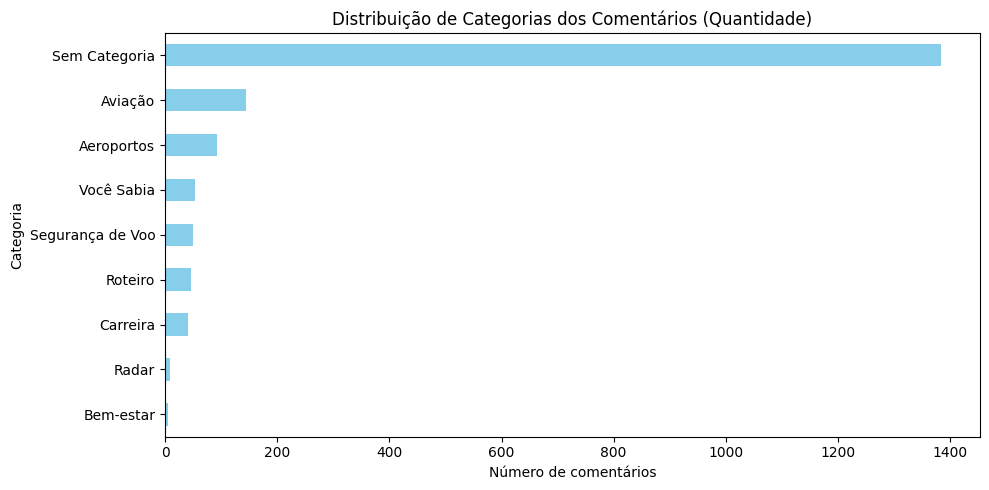

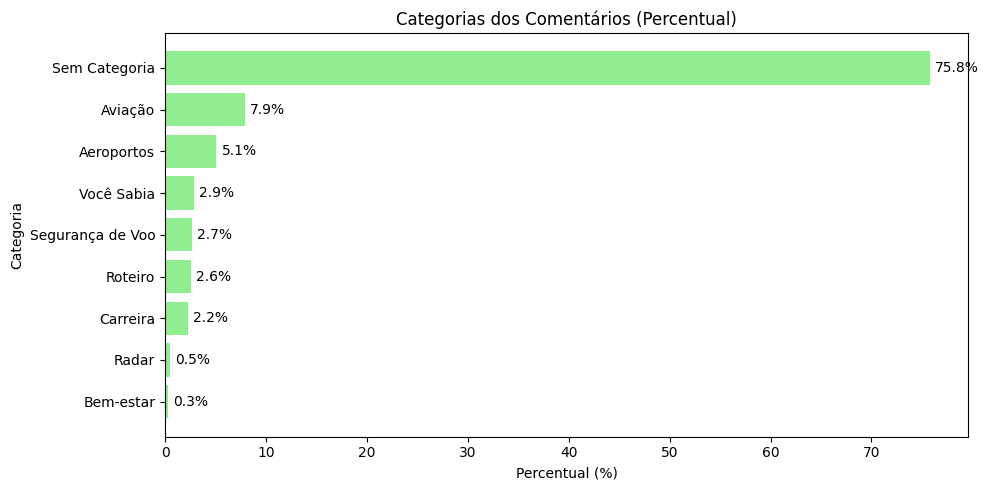

In [21]:
# Extração de Categorias baseada em Regras Keyword Matching
# O Objetivo deste código é extrair temas dos comentários através de técnicas de NLP
# Um dicionario de termos foi colocado e através dele extraiu-se as palavras

# CATEGORIAS (REGRAS)


categorias_keywords = {
    "Radar": [
        "radar", "meteorologia", "clima", "tempestade", "nuvens", "previsão"
    ],
    "Segurança de Voo": [
        "segurança", "incidente", "acidente", "queda", "colisão",
        "procedimento", "emergência", "falha", "risco", "aterrissagem forçada"
    ],
    "Aeroportos": [
        "aeroporto", "terminal", "check-in", "embarque", "desembarque",
        "fila", "esteira", "bagagem", "alfândega"
    ],
    "Roteiro": [
        "viagem", "destino", "roteiro", "turismo", "passagem",
        "hotel", "conexão", "escala", "itinerário"
    ],
    "Aviação": [
        "avião", "aeronave", "voo", "piloto", "copiloto",
        "turbina", "turbulência", "cabine", "cockpit", "hangar"
    ],
    "Bem-estar": [
        "cansaço", "estresse", "saúde", "bem-estar", "sono",
        "ansiedade", "fadiga", "descanso"
    ],
    "Carreira": [
        "carreira", "emprego", "vaga", "profissão", "curso",
        "formação", "treinamento", "salário", "promoção"
    ],
    "Você Sabia": [
        "você sabia", "curiosidade", "sabia que", "dica", "informação",
        "história", "fato"
    ]
}


# FUNÇÃO DE CLASSIFICAÇÃO

def detectar_categorias(texto):
    texto = str(texto).lower()
    categorias_encontradas = []
    for categoria, palavras in categorias_keywords.items():
        for palavra in palavras:
            if palavra in texto:
                categorias_encontradas.append(categoria)
                break
    if len(categorias_encontradas) == 0:
        return ["Sem Categoria"]
    return categorias_encontradas


# APLICA NO DATASET (treino e novo_banco)

comentarios["categorias"] = comentarios["comentario_limpo"].apply(detectar_categorias)
novo_banco["categorias"] = novo_banco["comentario_limpo"].apply(detectar_categorias)


# EXPLODIR (PARA ANÁLISE DE FREQUÊNCIA)

df_cat = comentarios.explode("categorias")


# FREQUÊNCIA (QUANTIDADE) DE CATEGORIAS

freq_cat = df_cat["categorias"].value_counts()

# Gráfico de barras horizontal com QUANTIDADE (sem grid)
plt.figure(figsize=(10,5))
freq_cat.sort_values().plot(kind="barh", color="skyblue")
plt.title("Distribuição de Categorias dos Comentários (Quantidade)")
plt.xlabel("Número de comentários")
plt.ylabel("Categoria")
plt.grid(False)
plt.tight_layout()
plt.show()


# PERCENTUAL DAS CATEGORIAS (gráfico de barras com rótulos, sem grid)

total_categorias = freq_cat.sum()
freq_cat_pct = (freq_cat / total_categorias) * 100
freq_cat_pct_sorted = freq_cat_pct.sort_values()

plt.figure(figsize=(10,5))
bars = plt.barh(freq_cat_pct_sorted.index, freq_cat_pct_sorted.values, color="lightgreen")
plt.title("Categorias dos Comentários (Percentual)")
plt.xlabel("Percentual (%)")
plt.ylabel("Categoria")
plt.grid(False)

# Adiciona rótulos de percentual nas barras
for bar, pct in zip(bars, freq_cat_pct_sorted.values):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f"{pct:.1f}%", va='center')

plt.tight_layout()
plt.show()





[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Total de comentários antes da limpeza: 1310
Total de comentários após limpeza: 1310

Distribuição dos sentimentos:

Sentimento
positivo    1150
negativo      90
neutro        70
Name: count, dtype: int64


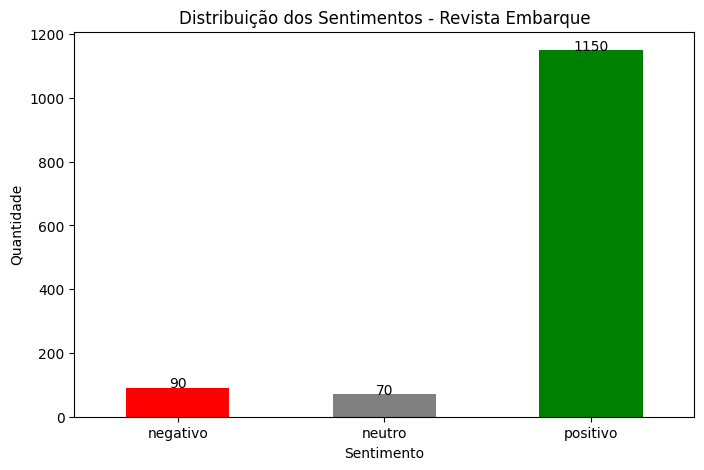


Emojis únicos encontrados (134):
{'💅🏻', '🌾', '😂', '😄', '🏄', '🌊', '👉', '🍻', '🧘', '🌺', '👍🏼', '🙏', '☕', '🌹', '🤗', '✈', '🍦', '😁', '🍀', '🙏🏻', '🤩', '✅', '😙', '🙏🏾', '🙌🏻', '🎈', '❤', '🕺🏻', '♨', '😱', '🙌🏼', '💝', '😝', '💪🏾', '🌵', '🐾', '👨\u200d🍳', '🔝', '📱', '👏🏻', '👏🏽', '🌍', '🛫', '😃', '💚', '😢', '🌸', '💎', '😌', '🧈', '🌼', '☺', '☁', '😆', '🛩', '🌻', '🎉', '👀', '🤡', '👏🏼', '💌', '🌲', '💯', '😊', '😀', '🇺🇸', '👍', '💙', '😉', '👍🏾', '✨', '🍷', '🌴', '👏🏿', '🙌🏾', '😭', '⛵', '🇺🇲', '😖', '🆒', '🙏🏽', '😍', '✈️', '🚕', '❤️', '🛬', '☺️', '⏬', '👁', '🤤', '📷', '🌷', '👱', '💔', '👍🏻', '💜', '😳', '4️⃣', '🤮', '✌', '✌️', '🌎', '👏🏾', '🐲', '👌🏻', '☀', '💲', '👋', '👊🏽', '👊', '🔥', '😘', '🚁', '👋🏻', '😎', '👌', '🥰', '🙌🏽', '🌞', '💪', '📸', '⭐', '🧡', '👌🏼', '💥', '💕', '🤙', '🏊', '🇲🇦', '🥂', '😜', '🤔', '👏', '🙌'}

Arquivo 'emojis.xlsx' gerado com sucesso.


In [22]:
# Extração de Emojis Únicos
# somente colunas de comentarios



import nltk
import spacy
import pandas as pd
import matplotlib.pyplot as plt
import emoji

# Certifique-se de ter as bibliotecas instaladas:
# !pip install emoji spacy nltk

nltk.download('stopwords')
nlp = spacy.load("pt_core_news_sm")

# =========================
# IMPORTAÇÃO DOS DADOS
# =========================
df_embarque = pd.read_excel('comments_embarque.xlsx')

# REMOVENDO AS COLUNAS SOLICITADAS
# Utilizamos errors='ignore' para evitar erros caso alguma coluna já não exista
colunas_para_remover = ['ID do usuário', 'Nome de usuário', 'Página inicial do usuário', 'URL do avatar']
df_embarque = df_embarque.drop(columns=colunas_para_remover, errors='ignore')

# Criando o banco apenas com a coluna de comentários para o processamento
novo_banco = df_embarque[['Comente']].copy()
novo_banco.columns = ['comentario']


# =========================
# PRÉ-PROCESSAMENTO
# =========================
# OBS: Certifique-se de que a função 'limpar_comentarios' está definida no seu script
novo_banco['comentario_limpo'] = novo_banco['comentario'].apply(limpar_comentarios)

print("Total de comentários antes da limpeza:", len(novo_banco))
novo_banco = novo_banco.dropna(subset=['comentario_limpo'])
print("Total de comentários após limpeza:", len(novo_banco))


# =========================
# CLASSIFICAÇÃO DE SENTIMENTO
# =========================
# OBS: O objeto 'pipeline' deve estar definido/treinado anteriormente
novo_banco['Sentimento'] = pipeline.predict(novo_banco['comentario_limpo'])


# =========================
# VISUALIZAÇÃO
# =========================
print("\nDistribuição dos sentimentos:\n")
print(novo_banco['Sentimento'].value_counts())

# Gráfico de Barras
ordem = ['negativo', 'neutro', 'positivo']
polaridades = novo_banco['Sentimento'].value_counts().reindex(ordem)

plt.figure(figsize=(8,5))
polaridades.plot(kind='bar', color=['red', 'gray', 'green'])
plt.title('Distribuição dos Sentimentos - Revista Embarque')
plt.xlabel('Sentimento')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)

for i, v in enumerate(polaridades.values):
    if pd.notnull(v):
        plt.text(i, v + 0.5, str(int(v)), ha='center')
plt.show()


# =========================
# EXTRAÇÃO DE EMOJIS ÚNICOS
# =========================
somente_emojis = []
somente_textos = []

for p in novo_banco['comentario'].fillna(''):
    p = str(p)
    # extrai emojis
    lista_emojis = emoji.distinct_emoji_list(p)
    somente_emojis.append(lista_emojis)

    # remove emojis do texto
    texto_sem_emoji = emoji.replace_emoji(p, replace='')
    somente_textos.append(texto_sem_emoji.strip())

# Consolidando emojis únicos
emojis_unicos = set()
for lista in somente_emojis:
    emojis_unicos.update(lista)

print(f"\nEmojis únicos encontrados ({len(emojis_unicos)}):")
print(emojis_unicos)

banco_emojis = pd.DataFrame(list(emojis_unicos), columns=['emoji'])

# Exportação
banco_emojis.to_excel('emojis.xlsx', index=True)
print("\nArquivo 'emojis.xlsx' gerado com sucesso.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Dataset: 1310 linhas e 3 colunas

--- Estatísticas ---
       tamanho_texto  qtd_palavras   qtd_emojis
count    1310.000000   1310.000000  1310.000000
mean       16.951908      3.082443     1.412214
std        31.205252      5.580790     1.901590
min         0.000000      0.000000     0.000000
25%         0.000000      0.000000     0.000000
50%         5.000000      1.000000     1.000000
75%        18.000000      3.000000     2.000000
max       285.000000     46.000000    21.000000

--- Top 20 Palavras ---
      Palavra  Frequência
0       great          57
1        nice          38
2        love          29
3        cool          27
4    parabéns          26
5         and          18
6       legal          18
7       check          17
8   instagram          17
9         pic          17
10    awesome          17
11       page          16
12      todos          16
13       this          15
14        wow          15
15        you          15
16       foto          14
17        out       

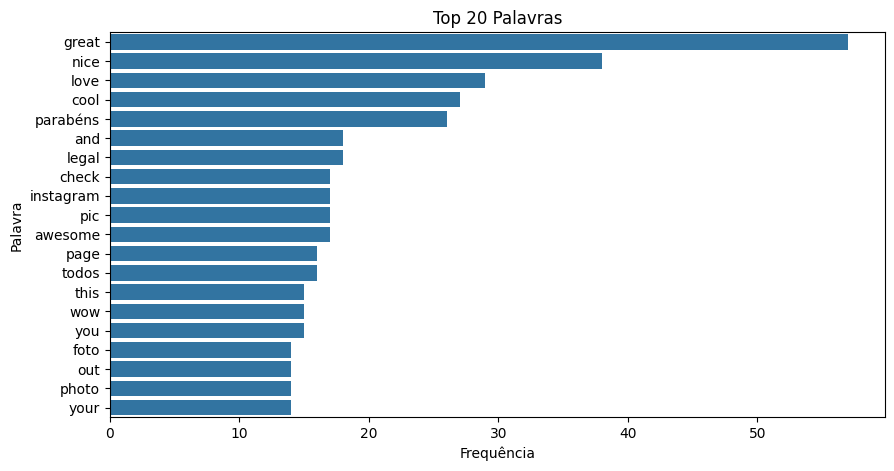

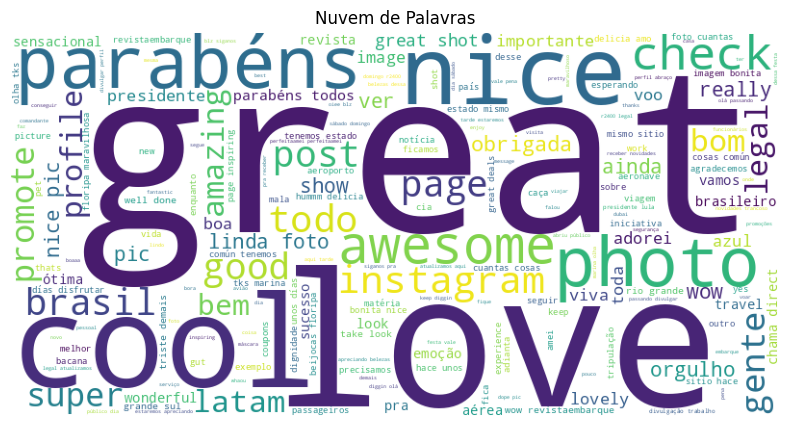


--- Top Emojis ---
   Emoji  Frequência
0      👏         498
1      👍         135
2      😍         103
3      😉          74
4      ❤          70
5      🔝          60
6      🏻          53
7      😊          51
8      ☺          43
9      🙌          40
10     😃          38
11     😢          38
12     ✌          35
13     😂          32
14     👌          28
15     😄          28
16     🏼          26
17     🙏          26
18     ✈          25
19     🌹          23


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128079 (\N{CLAPPING HANDS SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128285 (\N{TOP WITH UPWARDS ARROW ABOVE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127995 (\N{EMOJI MODIFIER FITZPATRICK TYPE-1-2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128588 (\N{PERSON RAISING BOTH HANDS IN CELEBRATION}) missing from font(s) DejaVu Sans.
 

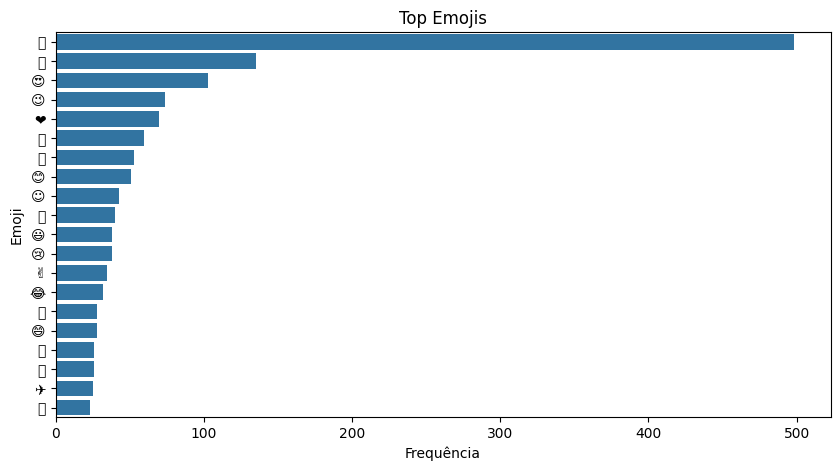


--- Emojis com significado ---
   Emoji  Frequência                               Significado
0      👏         498                         :mãos_aplaudindo:
1      👍         135                       :polegar_para_cima:
2      😍         103   :rosto_sorridente_com_olhos_de_coração:
3      😉          74                 :rosto_com_olho_piscando:
4      ❤          70                        :coração_vermelho:
5      🔝          60                                :seta_top:
6      🏻          53                              :pele_clara:
7      😊          51  :rosto_sorridente_com_olhos_sorridentes:
8      ☺          43                        :rosto_sorridente:
9      🙌          40                          :mãos_para_cima:
10     😃          38     :rosto_risonho_com_olhos_bem_abertos:
11     😢          38                          :rosto_chorando:
12     ✌          35                     :mão_em_v_de_vitória:
13     😂          32                   :rosto_chorando_de_rir:
14     👌          28   

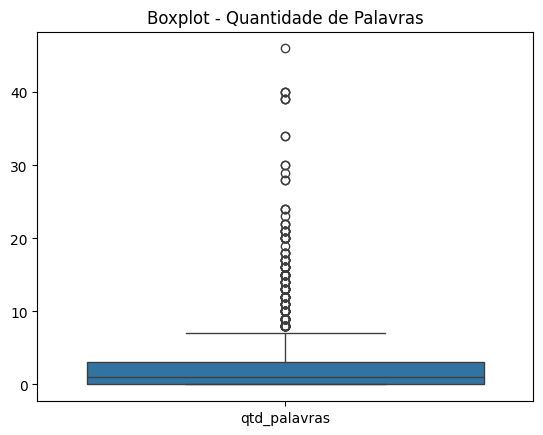

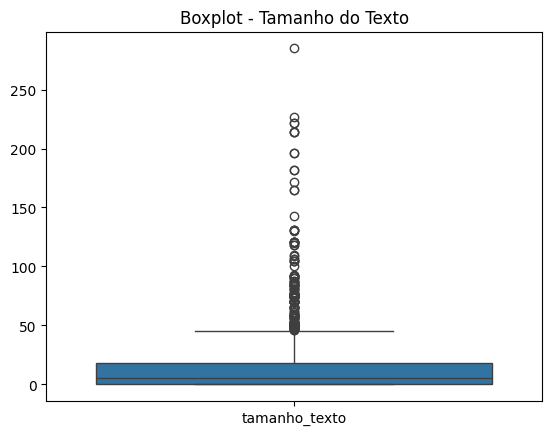

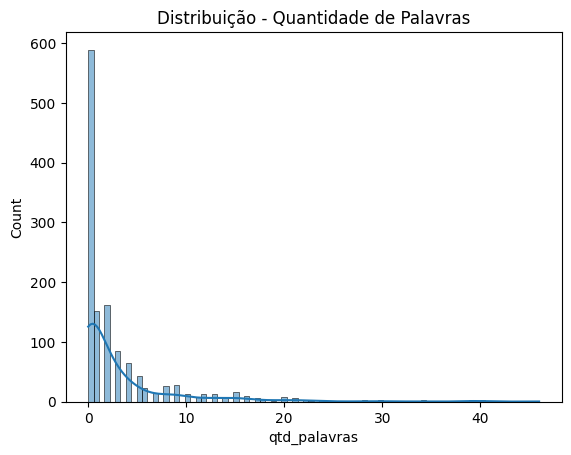

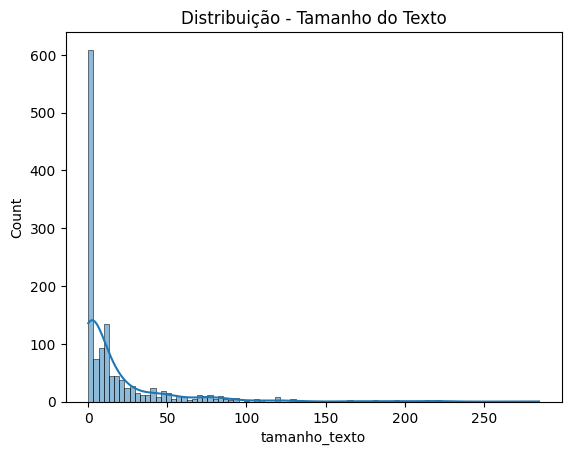

In [23]:

# ANALISE EXPLORATÓRIA SOMENTE COMENTARIOS EMBARQUE

# eMOJIS

# FREQUÊNCIA

import pandas as pd
import numpy as np
import re
import emoji
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

# Stopwords
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('portuguese'))


#  CARREGAR BASE

df = pd.read_excel('comments_embarque.xlsx')

print(f"Dataset: {df.shape[0]} linhas e {df.shape[1]} colunas")


# LIMPEZA INICIAL
# ================================
df['Comente'] = df['Comente'].fillna('').astype(str)


#  EXTRAIR EMOJIS (ANTES DE LIMPAR)

def extrair_emojis(texto):
    return [c for c in texto if c in emoji.EMOJI_DATA]

df['emojis'] = df['Comente'].apply(extrair_emojis)


#  LIMPAR TEXTO (SEM EMOJI)

def limpar_texto(texto):
    texto = re.sub(r'@\w+', '', texto)  # remove @
    texto = re.sub(r'http\S+|www\S+', '', texto)  # remove links
    texto = re.sub(r'#\w+', '', texto)  # remove hashtags
    texto = re.sub(r'[^\w\s]', '', texto)  # remove pontuação
    texto = texto.lower()
    texto = texto.strip()
    return texto

df['texto_limpo'] = df['Comente'].apply(limpar_texto)


# MÉTRICAS BÁSICAS

df['tamanho_texto'] = df['texto_limpo'].str.len()
df['qtd_palavras'] = df['texto_limpo'].apply(lambda x: len(x.split()))
df['qtd_emojis'] = df['emojis'].apply(len)


#  ESTATÍSTICAS

print("\n--- Estatísticas ---")
print(df[['tamanho_texto', 'qtd_palavras', 'qtd_emojis']].describe())


# TOKENIZAÇÃO

tokens = []

for texto in df['texto_limpo']:
    palavras = re.findall(r'\b\w+\b', texto)
    palavras = [p for p in palavras if p not in stop_words and len(p) > 2]
    tokens.extend(palavras)

#  FREQUÊNCIA DE PALAVRAS

freq_palavras = Counter(tokens)
top_20 = freq_palavras.most_common(20)

df_top = pd.DataFrame(top_20, columns=['Palavra', 'Frequência'])

print("\n--- Top 20 Palavras ---")
print(df_top)


#  GRÁFICO - TOP PALAVRAS

plt.figure(figsize=(10,5))
sns.barplot(data=df_top, x='Frequência', y='Palavra')
plt.title("Top 20 Palavras")
plt.show()


#  NUVEM DE PALAVRAS

if len(tokens) > 0:
    texto_wordcloud = " ".join(tokens)

    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(texto_wordcloud)

    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud)
    plt.axis('off')
    plt.title("Nuvem de Palavras")
    plt.show()
else:
    print("⚠️ Sem palavras suficientes para WordCloud")


#  ANÁLISE DE EMOJIS

todos_emojis = [e for lista in df['emojis'] for e in lista]

freq_emojis = Counter(todos_emojis)
top_emojis = freq_emojis.most_common(20)

df_emoji = pd.DataFrame(top_emojis, columns=['Emoji', 'Frequência'])

print("\n--- Top Emojis ---")
print(df_emoji)


#  GRÁFICO EMOJIS

if not df_emoji.empty:
    plt.figure(figsize=(10,5))
    sns.barplot(data=df_emoji, x='Frequência', y='Emoji')
    plt.title("Top Emojis")
    plt.show()
else:
    print("⚠️ Nenhum emoji encontrado")

#  SIGNIFICADO DOS EMOJIS

def significado_emoji(e):
    return emoji.demojize(e, language='pt')

df_emoji['Significado'] = df_emoji['Emoji'].apply(significado_emoji)

print("\n--- Emojis com significado ---")
print(df_emoji)


#  LISTA DE EMOJIS ÚNICOS

emojis_unicos = list(set(todos_emojis))

df_emojis_unicos = pd.DataFrame(emojis_unicos, columns=['Emoji'])

# adicionar significado
df_emojis_unicos['Significado'] = df_emojis_unicos['Emoji'].apply(significado_emoji)

print("\n--- Emojis Únicos ---")
print(df_emojis_unicos)

print(f"\nTotal de emojis únicos: {len(emojis_unicos)}")


#  BOXPLOT

plt.figure()
sns.boxplot(data=df[['qtd_palavras']])
plt.title("Boxplot - Quantidade de Palavras")
plt.show()

plt.figure()
sns.boxplot(data=df[['tamanho_texto']])
plt.title("Boxplot - Tamanho do Texto")
plt.show()


#  DISTRIBUIÇÃO

plt.figure()
sns.histplot(df['qtd_palavras'], kde=True)
plt.title("Distribuição - Quantidade de Palavras")
plt.show()

plt.figure()
sns.histplot(df['tamanho_texto'], kde=True)
plt.title("Distribuição - Tamanho do Texto")
plt.show()